# Explicabilidad e Interpretación de Modelos - Riesgos Laborales Colombia

Este notebook implementa análisis de explicabilidad con SHAP para interpretar los modelos de predicción de riesgos laborales, analizar características de clusters y anomalías, y generar recomendaciones accionables.

## Objetivos:
1. Implementar análisis SHAP para modelos de clasificación y regresión.
2. Interpretar características de clusters y anomalías.
3. Analizar casos específicos de alto y bajo riesgo.
4. Generar insights y recomendaciones para la prevención de riesgos laborales.
5. Crear visualizaciones explicativas para comunicación de resultados.

## 1. Configuración Inicial

### 1.1 Importar Librerías

Importamos las librerías necesarias para el análisis de explicabilidad.

In [174]:
# Instalar librerías necesarias
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib plotly kaleido nbformat

In [175]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Configuración de SHAP
shap.initjs()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Montar Google Drive (para Colab)

Si estás ejecutando este notebook en Google Colab, es necesario montar Google Drive para acceder a los archivos del proyecto.

In [176]:
# Verificar si estamos en Google Colab
try:
    from google.colab import drive
    # Montar Google Drive
    drive.mount('/content/drive')
    # Definir ruta base del proyecto en Google Drive
    BASE_PATH = '/content/drive/MyDrive/DatosARLBog'
    print(f"✅ Google Drive montado correctamente")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")
except:
    # Si no estamos en Colab, usar la ruta local
    BASE_PATH = '/Users/jualgozo/Documents/datoscol/DatosArl_Mac'
    print(f"💻 Ejecutando en entorno local")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")

💻 Ejecutando en entorno local
📁 Ruta base del proyecto: /Users/jualgozo/Documents/datoscol/DatosArl_Mac


### 1.3 Definir Rutas de Archivos

Definimos las rutas de los archivos del proyecto, incluyendo el dataset con clusters y los modelos entrenados.

In [177]:
# Definir rutas de archivos
DATA_PATH = Path(BASE_PATH)
PROCESSED_DATA_DIR = DATA_PATH / 'data' / 'processed'
MODELS_DIR = DATA_PATH / 'models'
REPORTS_DIR = DATA_PATH / 'reports'
SHAP_DIR = REPORTS_DIR / 'shap_analysis'

# Crear directorios si no existen
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Directorio de datos: {DATA_PATH}")
print(f"📁 Directorio de datos procesados: {PROCESSED_DATA_DIR}")
print(f"🤖 Directorio de modelos: {MODELS_DIR}")
print(f"📈 Directorio de reportes: {REPORTS_DIR}")
print(f"📊 Directorio de análisis SHAP: {SHAP_DIR}")

📂 Directorio de datos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac
📁 Directorio de datos procesados: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed
🤖 Directorio de modelos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/models
📈 Directorio de reportes: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports
📊 Directorio de análisis SHAP: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


## 2. Carga de Datos y Modelos

### 2.1 Cargar Dataset con Clusters y Anomalías

Cargamos el dataset procesado del notebook anterior que incluye las etiquetas de clusters y anomalías.

In [178]:
# Cargar el dataset con clusters y anomalías
try:
    dataset_path = PROCESSED_DATA_DIR / 'dataset_with_clusters.csv'
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset cargado correctamente desde: {dataset_path}")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo {dataset_path}")
    print("   Asegúrate de ejecutar primero el notebook 04_Analisis_Patrones.ipynb")
    raise

print(f"\n📊 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n📋 Columnas del dataset:")
print(df.columns.tolist())

✅ Dataset cargado correctamente desde: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed/dataset_with_clusters.csv

📊 Dimensiones del dataset: 61368 filas x 31 columnas

📋 Columnas del dataset:
['DPTO', 'MPIO', 'CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC', 'RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL', 'DPTO_encoded', 'MPIO_encoded', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP', 'TASA_PENSIONES_ACCIDENTE', 'TASA_PENSIONES_ENFERMEDAD', 'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES', 'CLUSTER_KMEANS', 'CLUSTER_DBSCAN', 'ANOMALY', 'ANOMALY_SCORE', 'FECHA']


In [179]:
# Mostrar las primeras filas del dataset
print("\n🔍 Primeras 5 filas del dataset:")
df.head()


🔍 Primeras 5 filas del dataset:


,DPTO,MPIO,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL,DPTO_encoded,MPIO_encoded,RELA_DEP_encoded,RELA_INDEP_encoded,TASA_ACCIDENTES_DEP,TASA_MUERTES_DEP,TASA_PENSIONES_ACCIDENTE,TASA_PENSIONES_ENFERMEDAD,TOTAL_PENSIONES,TOTAL_INCAPACIDADES,RATIO_INDEP_DEP,TOTAL_TRABAJADORES,CLUSTER_KMEANS,CLUSTER_DBSCAN,ANOMALY,ANOMALY_SCORE,FECHA
0,ANTIOQUIA,MEDELLIN,1423,2026,4,1131201,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,421,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,24.0,0,0,0,-0.346337,2026-04-01
1,ANTIOQUIA,MEDELLIN,1423,2026,4,1131202,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,188,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,10.0,0,0,0,-0.336481,2026-04-01
2,ANTIOQUIA,MEDELLIN,1423,2026,4,1139301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0,0,0,0,-0.318447,2026-04-01
3,ANTIOQUIA,MEDELLIN,1423,2026,4,1141001,688.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,905,214,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.04209,717.0,0,0,1,-0.653512,2026-04-01
4,ANTIOQUIA,MEDELLIN,1423,2026,4,1454101,323.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,1,516,551,0,0.006173,0.006173,0.666667,0.0,2.0,0.0,0.00000,323.0,0,0,1,-0.630471,2026-04-01


In [180]:
# Mostrar información del dataset
print("\n📋 Información del dataset:")
print(df.info())

print("\n📊 Estadísticas descriptivas:")
df.describe()


📋 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DPTO                       61368 non-null  str    
 1   MPIO                       61368 non-null  str    
 2   CODIGO_DE_LA_ARL           61368 non-null  int64  
 3   AÑO_DE_INFORME             61368 non-null  int64  
 4   MES_DE_INFORME             61368 non-null  int64  
 5   ACTIVEC                    61368 non-null  int64  
 6   RELA_DEP                   61368 non-null  float64
 7   RELA_INDEP                 61368 non-null  float64
 8   PRESUACCIDETRASUCE         61368 non-null  float64
 9   MUERTES_REPOR_AT           61368 non-null  float64
 10  NUEVAPENSIOINVA_R_AT       61368 non-null  float64
 11  NUEVAPENSIOINVA_R_EL       61368 non-null  float64
 12  INCAPERMAPARCIAR_AT        61368 non-null  float64
 13  INCAPERMAPARCIAR_EL        61

,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL,DPTO_encoded,MPIO_encoded,RELA_DEP_encoded,RELA_INDEP_encoded,TASA_ACCIDENTES_DEP,TASA_MUERTES_DEP,TASA_PENSIONES_ACCIDENTE,TASA_PENSIONES_ENFERMEDAD,TOTAL_PENSIONES,TOTAL_INCAPACIDADES,RATIO_INDEP_DEP,TOTAL_TRABAJADORES,CLUSTER_KMEANS,CLUSTER_DBSCAN,ANOMALY,ANOMALY_SCORE
count,61368.0,61368.0,61368.0,6.136800e+04,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,1423.0,2026.0,4.0,2.905466e+06,44.391083,8.663098,0.135005,0.135005,0.135005,0.000244,0.000147,0.000033,14.763721,504.418687,299.722820,19.739376,0.002031,0.002031,0.029810,0.000007,0.135250,0.000179,0.422111,53.054181,0.000945,0.000619,0.049896,-0.368526
std,0.0,0.0,0.0,1.294891e+06,614.021522,467.968900,1.894390,1.894390,1.894390,0.016642,0.012109,0.005709,9.540961,302.992084,331.924501,70.402446,0.025164,0.025164,0.133025,0.000844,1.899582,0.013387,7.399239,1010.197331,0.048094,0.056222,0.217731,0.091563
min,1423.0,2026.0,4.0,1.131201e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-0.827979
25%,1423.0,2026.0,4.0,1.841201e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,240.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.361682
50%,1423.0,2026.0,4.0,2.551101e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,501.000000,229.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-0.332010
75%,1423.0,2026.0,4.0,3.711001e+06,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,750.000000,536.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,-0.318447
max,1423.0,2026.0,4.0,5.960901e+06,89723.000000,107082.000000,256.000000,256.000000,256.000000,2.000000,1.000000,1.000000,32.000000,1032.000000,1088.000000,417.000000,2.000000,2.000000,0.996109,0.142857,258.000000,1.000000,631.000000,196805.000000,3.000000,3.000000,1.000000,-0.318447


### 2.2 Cargar Modelos Entrenados

Cargamos los modelos de clasificación, regresión, clustering y detección de anomalías entrenados en notebooks anteriores.

In [181]:
# Cargar modelos de clasificación
print("📦 Cargando modelos de clasificación...")

try:
    rf_classifier = joblib.load(MODELS_DIR / 'rf_classifier.pkl')
    print("   ✅ Random Forest Classifier cargado")
except FileNotFoundError:
    print("   ❌ Random Forest Classifier no encontrado")
    rf_classifier = None

try:
    xgb_classifier = joblib.load(MODELS_DIR / 'xgb_classifier.pkl')
    print("   ✅ XGBoost Classifier cargado")
except FileNotFoundError:
    print("   ❌ XGBoost Classifier no encontrado")
    xgb_classifier = None

try:
    log_reg = joblib.load(MODELS_DIR / 'log_reg.pkl')
    print("   ✅ Logistic Regression cargado")
except FileNotFoundError:
    print("   ❌ Logistic Regression no encontrado")
    log_reg = None

# Cargar label encoders
try:
    label_encoders = joblib.load(MODELS_DIR / 'label_encoders.pkl')
    print("   ✅ Label Encoders cargados")
except FileNotFoundError:
    print("   ❌ Label Encoders no encontrados")
    label_encoders = None

# Cargar modelos de regresión
print("\n📦 Cargando modelos de regresión...")

try:
    rf_regressor = joblib.load(MODELS_DIR / 'rf_regressor.pkl')
    print("   ✅ Random Forest Regressor cargado")
except FileNotFoundError:
    print("   ❌ Random Forest Regressor no encontrado")
    rf_regressor = None

try:
    xgb_regressor = joblib.load(MODELS_DIR / 'xgb_regressor.pkl')
    print("   ✅ XGBoost Regressor cargado")
except FileNotFoundError:
    print("   ❌ XGBoost Regressor no encontrado")
    xgb_regressor = None

try:
    lin_reg = joblib.load(MODELS_DIR / 'lin_reg.pkl')
    print("   ✅ Linear Regression cargado")
except FileNotFoundError:
    print("   ❌ Linear Regression no encontrado")
    lin_reg = None

# Cargar modelos de clustering y anomalías
print("\n📦 Cargando modelos de clustering y anomalías...")

try:
    kmeans = joblib.load(MODELS_DIR / 'kmeans_model.pkl')
    print("   ✅ K-Means cargado")
except FileNotFoundError:
    print("   ❌ K-Means no encontrado")
    kmeans = None

try:
    dbscan = joblib.load(MODELS_DIR / 'dbscan_model.pkl')
    print("   ✅ DBSCAN cargado")
except FileNotFoundError:
    print("   ❌ DBSCAN no encontrado")
    dbscan = None

try:
    iso_forest = joblib.load(MODELS_DIR / 'isolation_forest_model.pkl')
    print("   ✅ Isolation Forest cargado")
except FileNotFoundError:
    print("   ❌ Isolation Forest no encontrado")
    iso_forest = None

# Cargar scalers
print("\n📦 Cargando scalers...")

try:
    scaler_classification = joblib.load(MODELS_DIR / 'scaler_classification.pkl')
    print("   ✅ Scaler de clasificación cargado")
except FileNotFoundError:
    print("   ❌ Scaler de clasificación no encontrado")
    scaler_classification = None

try:
    scaler_regression = joblib.load(MODELS_DIR / 'scaler_regression.pkl')
    print("   ✅ Scaler de regresión cargado")
except FileNotFoundError:
    print("   ❌ Scaler de regresión no encontrado")
    scaler_regression = None

try:
    scaler_clustering = joblib.load(MODELS_DIR / 'scaler_clustering.pkl')
    print("   ✅ Scaler de clustering cargado")
except FileNotFoundError:
    print("   ❌ Scaler de clustering no encontrado")
    scaler_clustering = None

print("\n✅ Carga de modelos completada")

📦 Cargando modelos de clasificación...
   ✅ Random Forest Classifier cargado
   ✅ XGBoost Classifier cargado
   ✅ Logistic Regression cargado
   ✅ Label Encoders cargados

📦 Cargando modelos de regresión...
   ✅ Random Forest Regressor cargado
   ✅ XGBoost Regressor cargado
   ✅ Linear Regression cargado

📦 Cargando modelos de clustering y anomalías...
   ✅ K-Means cargado
   ✅ DBSCAN cargado
   ✅ Isolation Forest cargado

📦 Cargando scalers...
   ✅ Scaler de clasificación cargado
   ✅ Scaler de regresión cargado
   ✅ Scaler de clustering cargado

✅ Carga de modelos completada


### 2.3 Cargar Feature Importance

Cargamos los archivos de feature importance generados en el notebook de modelos de predicción.

In [182]:
# Cargar feature importance de modelos de clasificación
print("📊 Cargando feature importance...")

try:
    feature_importance_rf = pd.read_csv(REPORTS_DIR / 'feature_importance_rf_classifier.csv')
    print("   ✅ Feature importance de Random Forest Classifier cargado")
    print(f"   📋 {len(feature_importance_rf)} características")
except FileNotFoundError:
    print("   ❌ Feature importance de Random Forest Classifier no encontrado")
    feature_importance_rf = None

try:
    feature_importance_xgb = pd.read_csv(REPORTS_DIR / 'feature_importance_xgb_classifier.csv')
    print("   ✅ Feature importance de XGBoost Classifier cargado")
    print(f"   📋 {len(feature_importance_xgb)} características")
except FileNotFoundError:
    print("   ❌ Feature importance de XGBoost Classifier no encontrado")
    feature_importance_xgb = None

# Cargar estadísticas de clusters
try:
    cluster_stats = pd.read_csv(REPORTS_DIR / 'cluster_statistics.csv')
    print("\n   ✅ Estadísticas de clusters cargadas")
    print(f"   📋 {len(cluster_stats)} clusters")
except FileNotFoundError:
    print("   ❌ Estadísticas de clusters no encontradas")
    cluster_stats = None

print("\n✅ Carga de feature importance completada")

📊 Cargando feature importance...
   ✅ Feature importance de Random Forest Classifier cargado
   📋 10 características
   ✅ Feature importance de XGBoost Classifier cargado
   📋 10 características

   ✅ Estadísticas de clusters cargadas
   📋 4 clusters

✅ Carga de feature importance completada


In [183]:
# Mostrar feature importance de Random Forest
if feature_importance_rf is not None:
    print("\n📊 Feature Importance - Random Forest Classifier:")
    print(feature_importance_rf.head(10))


📊 Feature Importance - Random Forest Classifier:
              Feature  Importance
0  TOTAL_TRABAJADORES    0.419566
1            RELA_DEP    0.304709
2    RELA_DEP_encoded    0.142593
3     RATIO_INDEP_DEP    0.034855
4          RELA_INDEP    0.033405
5  RELA_INDEP_encoded    0.026942
6                MPIO    0.012457
7        MPIO_encoded    0.012260
8                DPTO    0.006642
9        DPTO_encoded    0.006571


In [184]:
# Mostrar feature importance de XGBoost
if feature_importance_xgb is not None:
    print("\n📊 Feature Importance - XGBoost Classifier:")
    print(feature_importance_xgb.head(10))


📊 Feature Importance - XGBoost Classifier:
              Feature  Importance
0  TOTAL_TRABAJADORES    0.603636
1            RELA_DEP    0.222413
2    RELA_DEP_encoded    0.042625
3          RELA_INDEP    0.031551
4     RATIO_INDEP_DEP    0.021229
5                MPIO    0.018439
6        MPIO_encoded    0.018315
7        DPTO_encoded    0.015575
8                DPTO    0.013918
9  RELA_INDEP_encoded    0.012299


In [185]:
# Mostrar estadísticas de clusters
if cluster_stats is not None:
    print("\n📊 Estadísticas de Clusters:")
    print(cluster_stats)


📊 Estadísticas de Clusters:
   CLUSTER_KMEANS      RELA_DEP     RELA_INDEP  PRESUACCIDETRASUCE  \
0               0     38.330991       5.995990            0.111113   
1               1  89723.000000  107082.000000          256.000000   
2               2  18127.600000    3777.066667           74.133333   
3               3   1246.333333       9.666667           11.222222   

   MUERTES_REPOR_AT  NUEVAPENSIOINVA_R_AT  NUEVAPENSIOINVA_R_EL  \
0          0.111113              0.111113              0.000196   
1        256.000000            256.000000              2.000000   
2         74.133333             74.133333              0.066667   
3         11.222222             11.222222              0.000000   

   INCAPERMAPARCIAR_AT  INCAPERMAPARCIAR_EL  RELA_DEP_encoded  \
0                  0.0             0.000016        299.630634   
1                  0.0             1.000000       1034.000000   
2                  0.0             0.000000        478.600000   
3                  1.0  

### 2.4 Preparar Datos para Análisis SHAP

Preparamos los datos necesarios para el análisis SHAP, incluyendo la preparación de features y targets.

In [186]:
# Preparar datos para análisis SHAP
print("🔧 Preparando datos para análisis SHAP...")

# Definir columnas a excluir (variables objetivo y derivadas)
# NOTA: Se excluyen las mismas variables que en el notebook 03, más las variables de clusters y anomalías del notebook 04
exclude_cols = ['CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC',
                # Variables objetivo
                'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 
                'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL',
                'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL',
                # Variables derivadas con fuga de datos
                'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP',
                'TASA_PENSIONES_ACCIDENTE', 'TASA_PENSIONES_ENFERMEDAD',
                'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES',
                # Variables de clusters y anomalías (del notebook 04)
                'CLUSTER_KMEANS', 'CLUSTER_DBSCAN', 'ANOMALY', 'ANOMALY_SCORE', 'FECHA']

# Seleccionar features
feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f"\n📋 Features seleccionadas ({len(feature_cols)}):")
print(feature_cols)

# Crear dataset de features
X = df[feature_cols].copy()

# Codificar variables categóricas usando los label encoders del notebook 03
if label_encoders is not None:
    print("\n🔧 Codificando variables categóricas...")
    for col in X.select_dtypes(include=['object']).columns:
        if col in label_encoders:
            print(f"   Codificando {col}...")
            X[col] = label_encoders[col].transform(X[col].astype(str))
        else:
            print(f"   ⚠️ Label encoder no encontrado para {col}, usando codificación manual")
            # Si no existe el encoder, crear uno nuevo
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
    print("✅ Variables categóricas codificadas correctamente")
else:
    print("\n⚠️ Label encoders no disponibles, codificando manualmente...")
    from sklearn.preprocessing import LabelEncoder
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Manejar valores faltantes
print("\n🔧 Manejando valores faltantes...")
for col in X.select_dtypes(include=[np.number]).columns:
    X[col].fillna(X[col].median(), inplace=True)

print(f"✅ Valores faltantes imputados")

# Crear variable objetivo para clasificación (accidente > 0)
y_class = (df['PRESUACCIDETRASUCE'] > 0).astype(int)

# Crear variable objetivo para regresión (número de accidentes)
y_reg = df['PRESUACCIDETRASUCE'].values

print(f"\n📊 Dimensiones de X: {X.shape}")
print(f"📊 Dimensiones de y_class: {y_class.shape}")
print(f"📊 Dimensiones de y_reg: {y_reg.shape}")

# Dividir en train y test
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

_, X_test_reg, _, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"\n📊 Dimensiones de X_train: {X_train.shape}")
print(f"📊 Dimensiones de X_test: {X_test.shape}")
print(f"📊 Dimensiones de X_test_reg: {X_test_reg.shape}")

# Escalar datos si el scaler está disponible
if scaler_classification is not None:
    X_train_scaled = scaler_classification.transform(X_train)
    X_test_scaled = scaler_classification.transform(X_test)
    print("\n✅ Datos escalados correctamente")
else:
    X_train_scaled = X_train.values
    X_test_scaled = X_test.values
    print("\n⚠️ Scaler no disponible, usando datos sin escalar")

print("\n✅ Preparación de datos completada")

🔧 Preparando datos para análisis SHAP...

📋 Features seleccionadas (10):
['DPTO', 'MPIO', 'RELA_DEP', 'RELA_INDEP', 'DPTO_encoded', 'MPIO_encoded', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES']

🔧 Codificando variables categóricas...
   Codificando DPTO...
   Codificando MPIO...
✅ Variables categóricas codificadas correctamente

🔧 Manejando valores faltantes...
✅ Valores faltantes imputados

📊 Dimensiones de X: (61368, 10)
📊 Dimensiones de y_class: (61368,)
📊 Dimensiones de y_reg: (61368,)

📊 Dimensiones de X_train: (49094, 10)
📊 Dimensiones de X_test: (12274, 10)
📊 Dimensiones de X_test_reg: (12274, 10)

✅ Datos escalados correctamente

✅ Preparación de datos completada


## 3. Análisis SHAP para Modelos de Clasificación

### 3.1 Random Forest Classifier

Implementamos análisis SHAP para el modelo de Random Forest Classifier.

🔍 Analizando Random Forest Classifier con SHAP...
   📦 Creando TreeExplainer...
   📊 Calculando SHAP values para 100 muestras...
   ✅ SHAP values calculados: (100, 10, 2)

   📈 Generando summary plot...


<Figure size 1200x800 with 0 Axes>

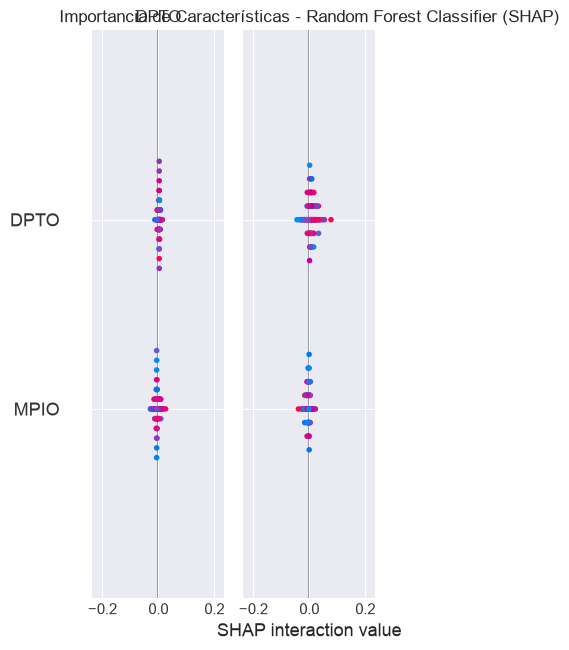

<Figure size 1200x800 with 0 Axes>

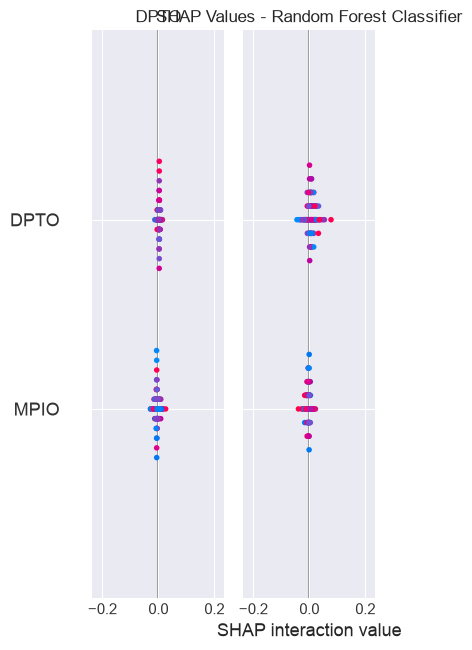


✅ Análisis SHAP para Random Forest Classifier completado
   📊 Gráficos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


In [187]:
# Análisis SHAP para Random Forest Classifier
print("🔍 Analizando Random Forest Classifier con SHAP...")

if rf_classifier is not None:
    # Crear explainer SHAP para Random Forest
    print("   📦 Creando TreeExplainer...")
    explainer_rf = shap.TreeExplainer(rf_classifier)
    
    # Calcular SHAP values para una muestra del conjunto de test
    # Usamos una muestra para reducir tiempo de cómputo
    sample_size = min(100, len(X_test))
    X_test_sample = X_test.iloc[:sample_size]
    
    print(f"   📊 Calculando SHAP values para {sample_size} muestras...")
    shap_values_rf = explainer_rf.shap_values(X_test_sample)
    
    # Para clasificación binaria, shap_values es una lista con dos elementos
    # Nos interesa la clase positiva (índice 1)
    if isinstance(shap_values_rf, list):
        shap_values_rf_positive = shap_values_rf[1]
    else:
        shap_values_rf_positive = shap_values_rf
    
    print(f"   ✅ SHAP values calculados: {shap_values_rf_positive.shape}")
    
    # Summary plot
    print("\n   📈 Generando summary plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_rf_positive, X_test_sample, plot_type="bar", show=False)
    plt.title('Importancia de Características - Random Forest Classifier (SHAP)')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_rf_classifier_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary plot con beeswarm
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_rf_positive, X_test_sample, show=False)
    plt.title('SHAP Values - Random Forest Classifier')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_rf_classifier_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis SHAP para Random Forest Classifier completado")
    print(f"   📊 Gráficos guardados en: {SHAP_DIR}")
else:
    print("❌ Random Forest Classifier no disponible")

### 3.2 XGBoost Classifier

Implementamos análisis SHAP para el modelo de XGBoost Classifier.

🔍 Analizando XGBoost Classifier con SHAP...
   📦 Creando TreeExplainer...
   📊 Calculando SHAP values para 100 muestras...
   ✅ SHAP values calculados: (100, 10)

   📈 Generando summary plot...


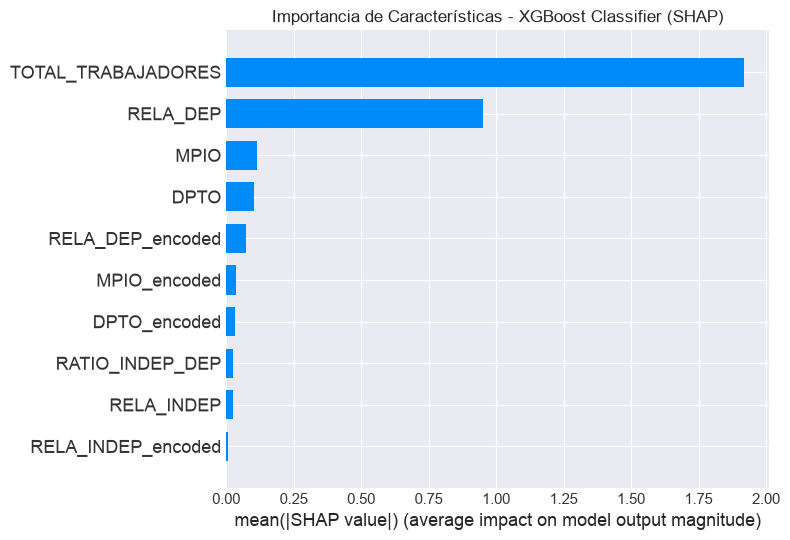

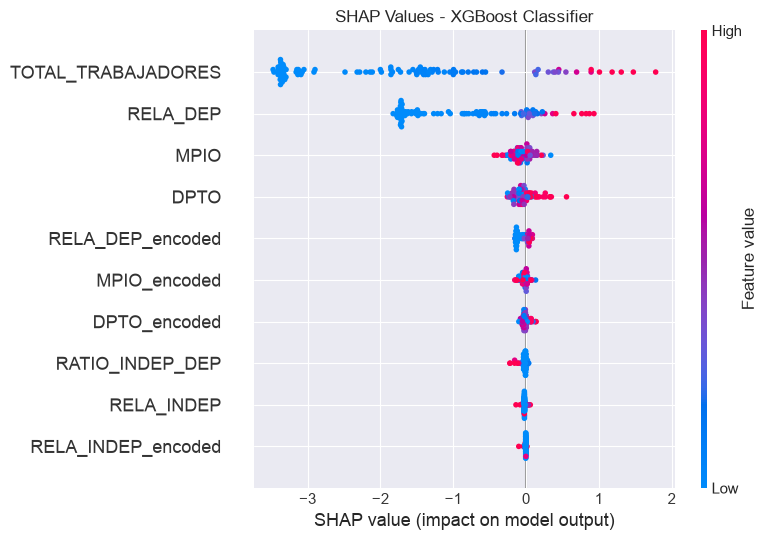


✅ Análisis SHAP para XGBoost Classifier completado
   📊 Gráficos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


In [188]:
# Análisis SHAP para XGBoost Classifier
print("🔍 Analizando XGBoost Classifier con SHAP...")

if xgb_classifier is not None:
    # Crear explainer SHAP para XGBoost
    print("   📦 Creando TreeExplainer...")
    explainer_xgb = shap.TreeExplainer(xgb_classifier)
    
    # Calcular SHAP values para una muestra del conjunto de test
    sample_size = min(100, len(X_test))
    X_test_sample = X_test.iloc[:sample_size]
    
    print(f"   📊 Calculando SHAP values para {sample_size} muestras...")
    shap_values_xgb = explainer_xgb.shap_values(X_test_sample)
    
    print(f"   ✅ SHAP values calculados: {shap_values_xgb.shape}")
    
    # Summary plot
    print("\n   📈 Generando summary plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_xgb, X_test_sample, plot_type="bar", show=False)
    plt.title('Importancia de Características - XGBoost Classifier (SHAP)')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_xgb_classifier_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary plot con beeswarm
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
    plt.title('SHAP Values - XGBoost Classifier')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_xgb_classifier_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis SHAP para XGBoost Classifier completado")
    print(f"   📊 Gráficos guardados en: {SHAP_DIR}")
else:
    print("❌ XGBoost Classifier no disponible")

### 3.3 Logistic Regression

Implementamos análisis SHAP para el modelo de Logistic Regression.

🔍 Analizando Logistic Regression con SHAP...
   📦 Creando LinearExplainer...
   📊 Calculando SHAP values para 100 muestras...
   ✅ SHAP values calculados: (100, 10)

   📈 Generando summary plot...


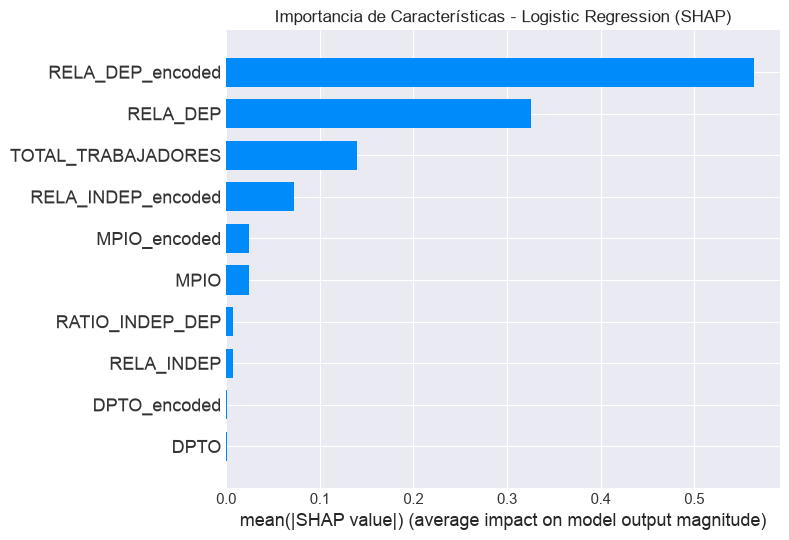

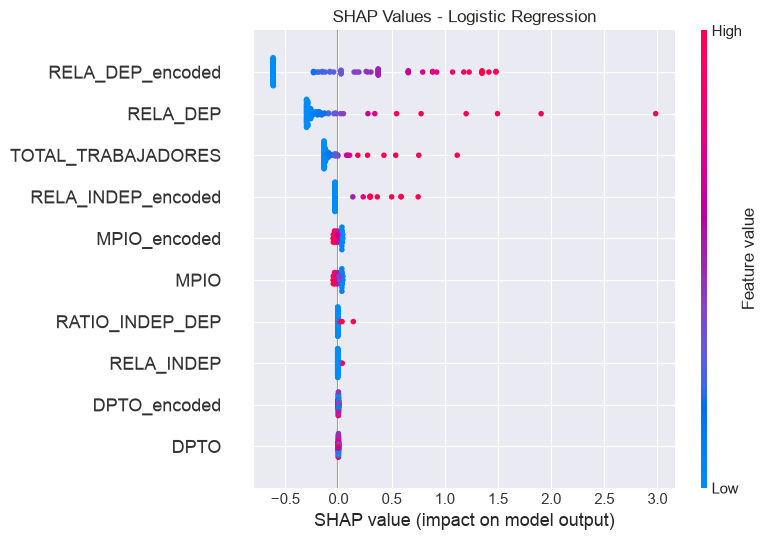


✅ Análisis SHAP para Logistic Regression completado
   📊 Gráficos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


In [189]:
# Análisis SHAP para Logistic Regression
print("🔍 Analizando Logistic Regression con SHAP...")

if log_reg is not None:
    # Crear explainer SHAP para Logistic Regression
    print("   📦 Creando LinearExplainer...")
    
    # Usar una muestra para el background
    background_size = min(100, len(X_train_scaled))
    background_data = shap.sample(X_train_scaled, background_size)
    
    explainer_lr = shap.LinearExplainer(log_reg, background_data)
    
    # Calcular SHAP values para una muestra del conjunto de test
    sample_size = min(100, len(X_test_scaled))
    X_test_sample_scaled = X_test_scaled[:sample_size]
    
    print(f"   📊 Calculando SHAP values para {sample_size} muestras...")
    shap_values_lr = explainer_lr.shap_values(X_test_sample_scaled)
    
    print(f"   ✅ SHAP values calculados: {shap_values_lr.shape}")
    
    # Summary plot
    print("\n   📈 Generando summary plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_lr, X_test_sample_scaled, feature_names=feature_cols, plot_type="bar", show=False)
    plt.title('Importancia de Características - Logistic Regression (SHAP)')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_log_reg_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary plot con beeswarm
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_lr, X_test_sample_scaled, feature_names=feature_cols, show=False)
    plt.title('SHAP Values - Logistic Regression')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_log_reg_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis SHAP para Logistic Regression completado")
    print(f"   📊 Gráficos guardados en: {SHAP_DIR}")
else:
    print("❌ Logistic Regression no disponible")

### 3.4 Comparación de Feature Importance

Comparamos la importancia de características entre los diferentes modelos de clasificación.

📊 Comparando feature importance de modelos de clasificación...


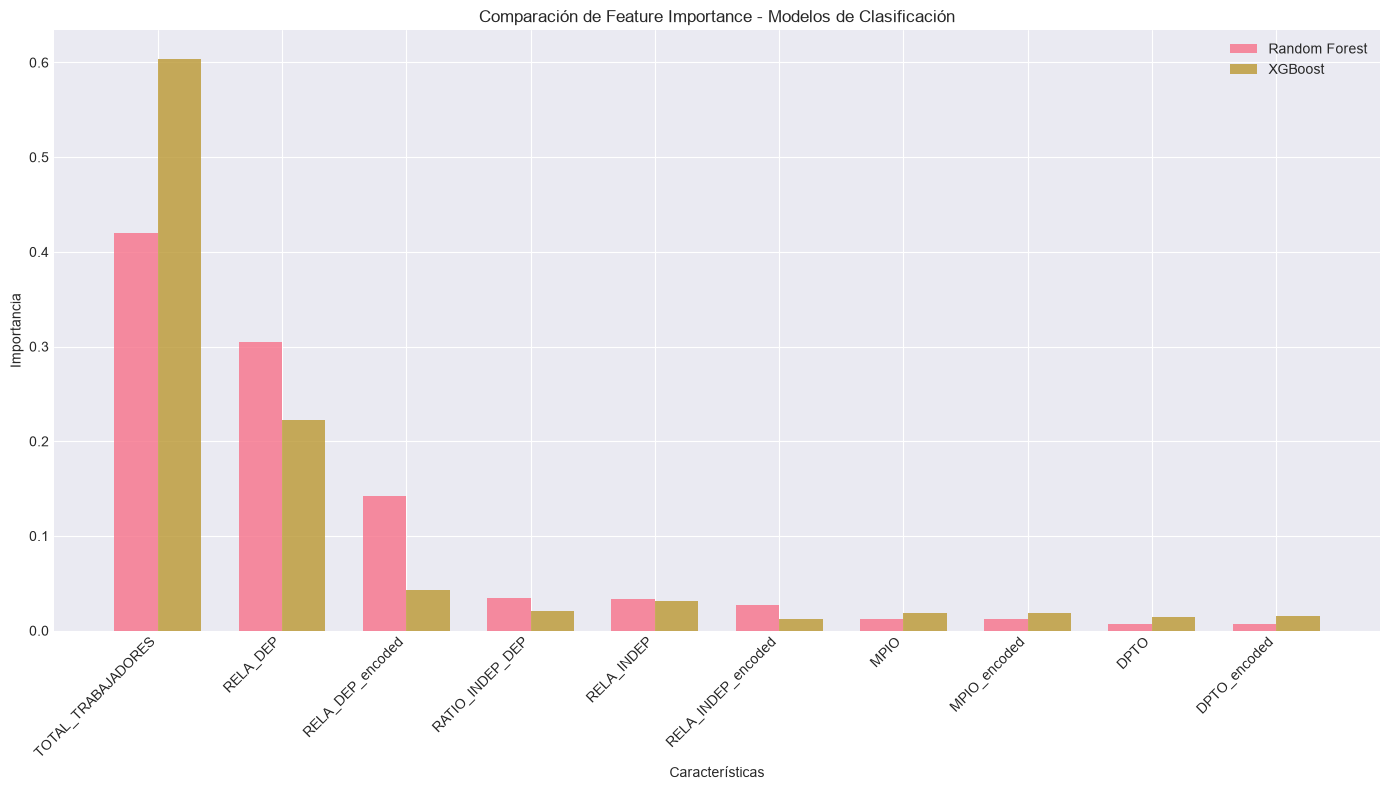


✅ Comparación de feature importance completada
   📊 Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis/feature_importance_comparison.png


In [190]:
# Comparar feature importance de modelos de clasificación
print("📊 Comparando feature importance de modelos de clasificación...")

# Crear DataFrame comparativo
comparison_data = []

# Random Forest feature importance
if feature_importance_rf is not None:
    for idx, row in feature_importance_rf.head(10).iterrows():
        comparison_data.append({
            'Feature': row['Feature'],
            'Model': 'Random Forest',
            'Importance': row['Importance']
        })

# XGBoost feature importance
if feature_importance_xgb is not None:
    for idx, row in feature_importance_xgb.head(10).iterrows():
        comparison_data.append({
            'Feature': row['Feature'],
            'Model': 'XGBoost',
            'Importance': row['Importance']
        })

# Crear DataFrame
df_comparison = pd.DataFrame(comparison_data)

# Visualizar comparación
if len(df_comparison) > 0:
    plt.figure(figsize=(14, 8))
    
    # Crear gráfico de barras agrupadas
    features = df_comparison['Feature'].unique()
    models = df_comparison['Model'].unique()
    
    x = np.arange(len(features))
    width = 0.35
    
    for i, model in enumerate(models):
        model_data = df_comparison[df_comparison['Model'] == model]
        # Ordenar por feature para alinear
        model_data_sorted = model_data.set_index('Feature').reindex(features).reset_index()
        plt.bar(x + i*width, model_data_sorted['Importance'], width, label=model, alpha=0.8)
    
    plt.xlabel('Características')
    plt.ylabel('Importancia')
    plt.title('Comparación de Feature Importance - Modelos de Clasificación')
    plt.xticks(x + width/2, features, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'feature_importance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Comparación de feature importance completada")
    print(f"   📊 Gráfico guardado en: {SHAP_DIR / 'feature_importance_comparison.png'}")
else:
    print("❌ No hay datos de feature importance disponibles")

## 4. Análisis SHAP para Modelos de Regresión

### 4.1 Random Forest Regressor

Implementamos análisis SHAP para el modelo de Random Forest Regressor.

🔍 Analizando Random Forest Regressor con SHAP...
   📦 Creando TreeExplainer...
   📊 Calculando SHAP values para 100 muestras...
   ✅ SHAP values calculados: (100, 10)

   📈 Generando summary plot...


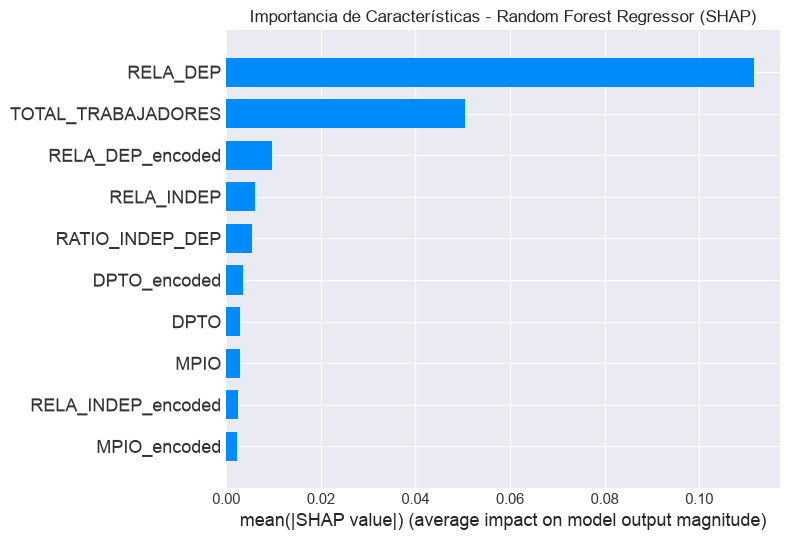

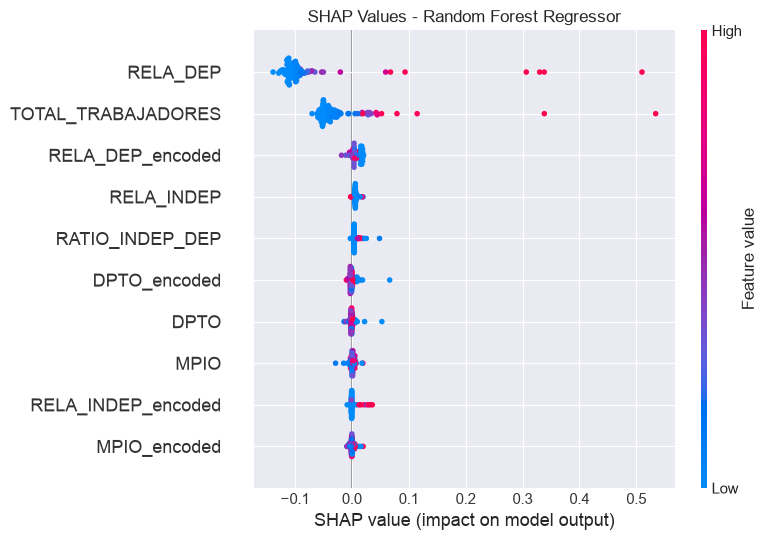


✅ Análisis SHAP para Random Forest Regressor completado
   📊 Gráficos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


In [191]:
# Análisis SHAP para Random Forest Regressor
print("🔍 Analizando Random Forest Regressor con SHAP...")

if rf_regressor is not None:
    # Crear explainer SHAP para Random Forest Regressor
    print("   📦 Creando TreeExplainer...")
    explainer_rf_reg = shap.TreeExplainer(rf_regressor)
    
    # Calcular SHAP values para una muestra del conjunto de test
    sample_size = min(100, len(X_test_reg))
    X_test_reg_sample = X_test_reg.iloc[:sample_size]
    
    print(f"   📊 Calculando SHAP values para {sample_size} muestras...")
    shap_values_rf_reg = explainer_rf_reg.shap_values(X_test_reg_sample)
    
    print(f"   ✅ SHAP values calculados: {shap_values_rf_reg.shape}")
    
    # Summary plot
    print("\n   📈 Generando summary plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_rf_reg, X_test_reg_sample, plot_type="bar", show=False)
    plt.title('Importancia de Características - Random Forest Regressor (SHAP)')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_rf_regressor_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary plot con beeswarm
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_rf_reg, X_test_reg_sample, show=False)
    plt.title('SHAP Values - Random Forest Regressor')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_rf_regressor_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis SHAP para Random Forest Regressor completado")
    print(f"   📊 Gráficos guardados en: {SHAP_DIR}")
else:
    print("❌ Random Forest Regressor no disponible")

### 4.2 XGBoost Regressor

Implementamos análisis SHAP para el modelo de XGBoost Regressor.

🔍 Analizando XGBoost Regressor con SHAP...
   📦 Creando TreeExplainer...
   📊 Calculando SHAP values para 100 muestras...
   ✅ SHAP values calculados: (100, 10)

   📈 Generando summary plot...


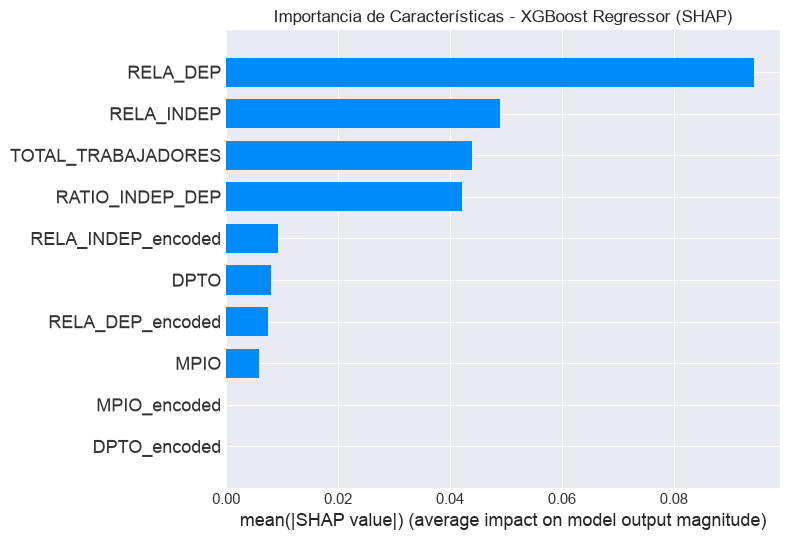

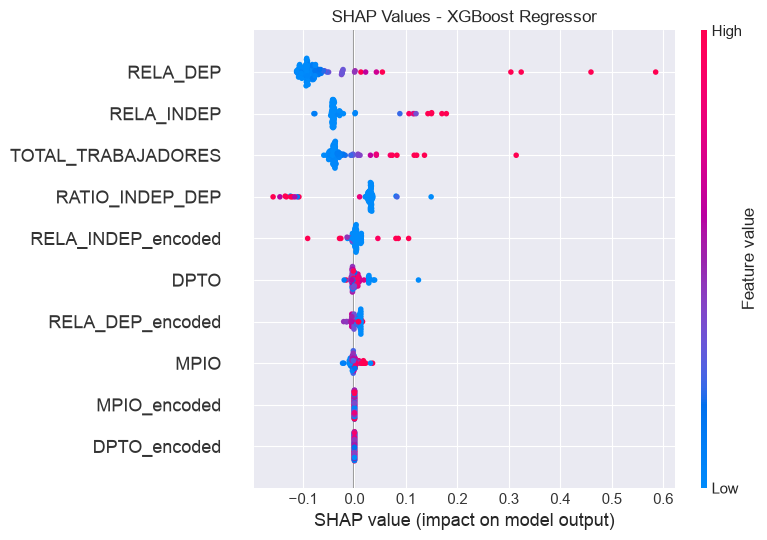


✅ Análisis SHAP para XGBoost Regressor completado
   📊 Gráficos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


In [192]:
# Análisis SHAP para XGBoost Regressor
print("🔍 Analizando XGBoost Regressor con SHAP...")

if xgb_regressor is not None:
    # Crear explainer SHAP para XGBoost Regressor
    print("   📦 Creando TreeExplainer...")
    explainer_xgb_reg = shap.TreeExplainer(xgb_regressor)
    
    # Calcular SHAP values para una muestra del conjunto de test
    sample_size = min(100, len(X_test_reg))
    X_test_reg_sample = X_test_reg.iloc[:sample_size]
    
    print(f"   📊 Calculando SHAP values para {sample_size} muestras...")
    shap_values_xgb_reg = explainer_xgb_reg.shap_values(X_test_reg_sample)
    
    print(f"   ✅ SHAP values calculados: {shap_values_xgb_reg.shape}")
    
    # Summary plot
    print("\n   📈 Generando summary plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_xgb_reg, X_test_reg_sample, plot_type="bar", show=False)
    plt.title('Importancia de Características - XGBoost Regressor (SHAP)')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_xgb_regressor_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary plot con beeswarm
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_xgb_reg, X_test_reg_sample, show=False)
    plt.title('SHAP Values - XGBoost Regressor')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_xgb_regressor_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis SHAP para XGBoost Regressor completado")
    print(f"   📊 Gráficos guardados en: {SHAP_DIR}")
else:
    print("❌ XGBoost Regressor no disponible")

### 4.3 Linear Regression

Implementamos análisis SHAP para el modelo de Linear Regression.

🔍 Analizando Linear Regression con SHAP...
   📦 Creando LinearExplainer...
   📊 Calculando SHAP values para 100 muestras...
   ✅ SHAP values calculados: (100, 10)

   📈 Generando summary plot...


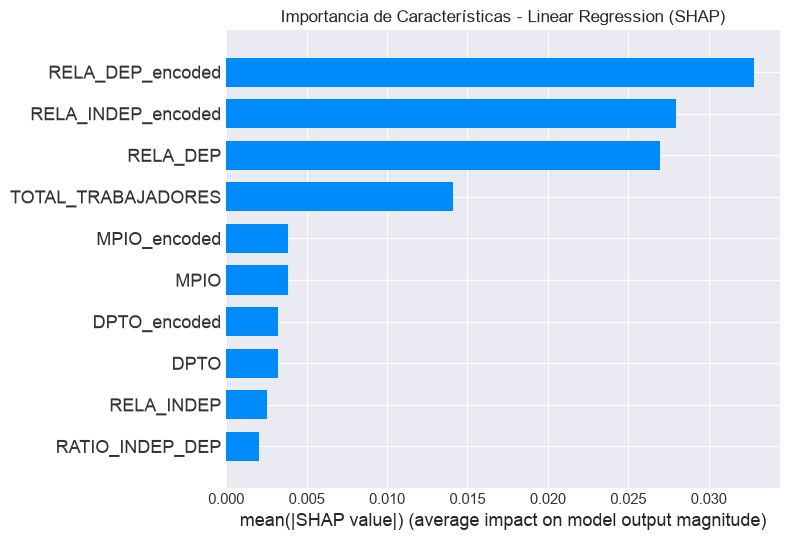

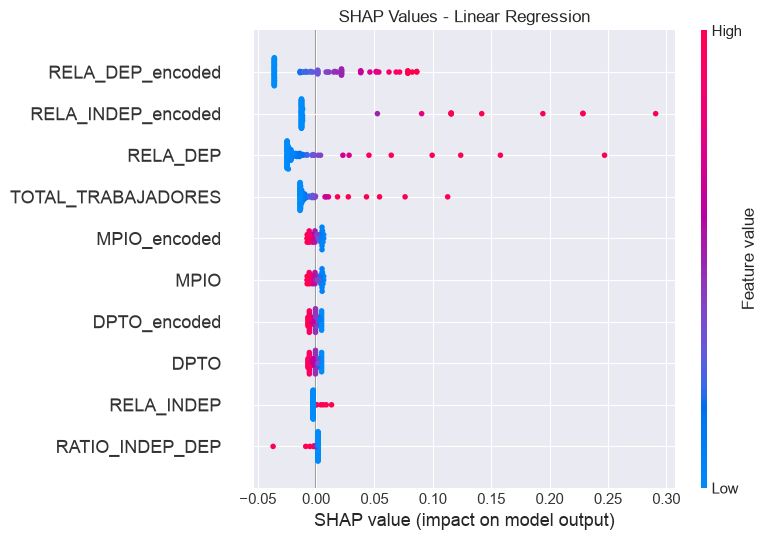


✅ Análisis SHAP para Linear Regression completado
   📊 Gráficos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis


In [193]:
# Análisis SHAP para Linear Regression
print("🔍 Analizando Linear Regression con SHAP...")

if lin_reg is not None:
    # Crear explainer SHAP para Linear Regression
    print("   📦 Creando LinearExplainer...")
    
    # Usar una muestra para el background
    background_size = min(100, len(X_train_scaled))
    background_data = shap.sample(X_train_scaled, background_size)
    
    explainer_lin_reg = shap.LinearExplainer(lin_reg, background_data)
    
    # Calcular SHAP values para una muestra del conjunto de test
    sample_size = min(100, len(X_test_scaled))
    X_test_sample_scaled = X_test_scaled[:sample_size]
    
    print(f"   📊 Calculando SHAP values para {sample_size} muestras...")
    shap_values_lin_reg = explainer_lin_reg.shap_values(X_test_sample_scaled)
    
    print(f"   ✅ SHAP values calculados: {shap_values_lin_reg.shape}")
    
    # Summary plot
    print("\n   📈 Generando summary plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_lin_reg, X_test_sample_scaled, feature_names=feature_cols, plot_type="bar", show=False)
    plt.title('Importancia de Características - Linear Regression (SHAP)')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_lin_reg_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary plot con beeswarm
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_lin_reg, X_test_sample_scaled, feature_names=feature_cols, show=False)
    plt.title('SHAP Values - Linear Regression')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'shap_summary_lin_reg_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis SHAP para Linear Regression completado")
    print(f"   📊 Gráficos guardados en: {SHAP_DIR}")
else:
    print("❌ Linear Regression no disponible")

## 5. Interpretación de Clusters y Anomalías

### 5.1 Análisis de Clusters K-Means

Analizamos las características de cada cluster identificado por K-Means.

📊 Analizando clusters K-Means...

📊 Estadísticas por cluster:
                    RELA_DEP                          RELA_INDEP               \
                        mean           std  count           mean          std   
CLUSTER_KMEANS                                                                  
0                  38.330991    333.219700  61343       5.995990    99.294038   
1               89723.000000           NaN      1  107082.000000          NaN   
2               18127.600000  15458.380990     15    3777.066667  9087.349908   
3                1246.333333   1483.149773      9       9.666667    16.332483   

                      PRESUACCIDETRASUCE                   MUERTES_REPOR_AT  \
                count               mean        std  count             mean   
CLUSTER_KMEANS                                                                
0               61343           0.111113   0.850585  61343         0.111113   
1                   1         256.000000        NaN   

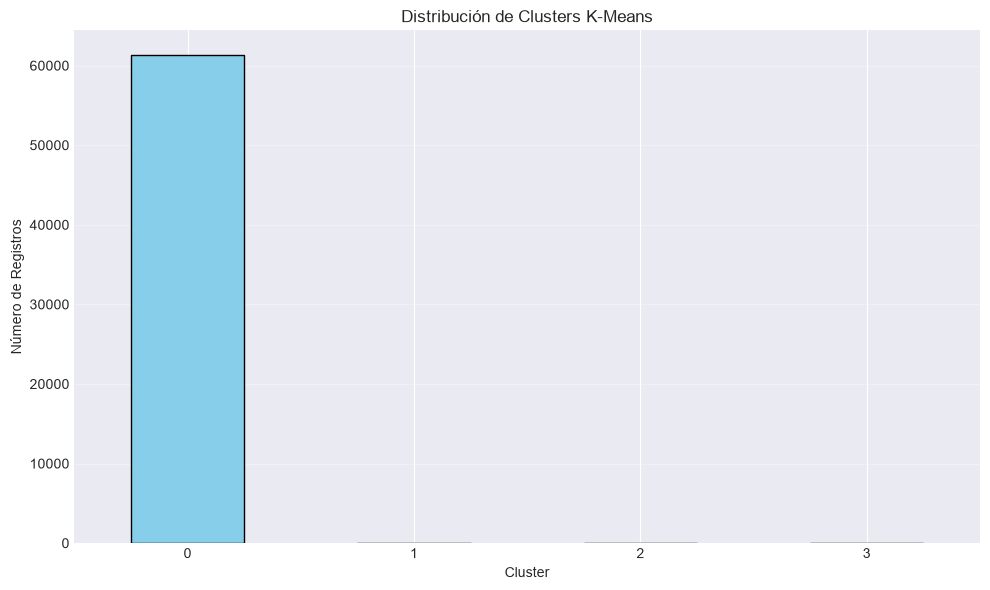


✅ Análisis de clusters completado
   📊 Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis/cluster_distribution.png


In [194]:
# Análisis detallado de clusters K-Means
print("📊 Analizando clusters K-Means...")

if 'CLUSTER_KMEANS' in df.columns:
    # Estadísticas por cluster
    print("\n📊 Estadísticas por cluster:")
    
    # Variables numéricas para análisis
    numeric_vars = ['RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT',
                    'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 
                    'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL',
                    'TOTAL_TRABAJADORES', 'RATIO_INDEP_DEP']
    
    # Calcular estadísticas por cluster
    cluster_analysis = df.groupby('CLUSTER_KMEANS')[numeric_vars].agg(['mean', 'std', 'count'])
    
    print(cluster_analysis)
    
    # Distribución de clusters
    print("\n📊 Distribución de clusters:")
    cluster_dist = df['CLUSTER_KMEANS'].value_counts().sort_index()
    print(cluster_dist)
    
    # Visualizar distribución de clusters
    plt.figure(figsize=(10, 6))
    cluster_dist.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.xlabel('Cluster')
    plt.ylabel('Número de Registros')
    plt.title('Distribución de Clusters K-Means')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'cluster_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis de clusters completado")
    print(f"   📊 Gráfico guardado en: {SHAP_DIR / 'cluster_distribution.png'}")
else:
    print("❌ Columna CLUSTER_KMEANS no encontrada en el dataset")

In [195]:
# Características principales por cluster
print("📊 Características principales por cluster...")

if 'CLUSTER_KMEANS' in df.columns and cluster_stats is not None:
    # Mostrar estadísticas de clusters
    print("\n📊 Estadísticas de clusters:")
    print(cluster_stats)
    
    # Crear radar chart para comparar clusters
    print("\n📈 Creando radar chart para comparar clusters...")
    
    # Variables para el radar chart
    radar_vars = ['RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 
                  'MUERTES_REPOR_AT', 'TOTAL_TRABAJADORES']
    
    # Normalizar datos para el radar chart
    cluster_means = df.groupby('CLUSTER_KMEANS')[radar_vars].mean()
    cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
    
    # Crear radar chart
    fig = go.Figure()
    
    categories = radar_vars
    N = len(categories)
    
    # Ángulos para cada variable
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Cerrar el círculo
    
    # Añadir cada cluster al radar chart
    for cluster_id in cluster_means_normalized.index:
        values = cluster_means_normalized.loc[cluster_id].values.flatten().tolist()
        values += values[:1]  # Cerrar el círculo
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories,
            fill='toself',
            name=f'Cluster {cluster_id}',
            opacity=0.6
        ))
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1]
            )
        ),
        showlegend=True,
        title='Comparación de Clusters - Radar Chart'
    )
    
    # Intentar guardar como imagen, si falla mostrar solo interactivo
    try:
        fig.write_image(str(SHAP_DIR / 'cluster_radar_chart.png'))
        print(f"\n✅ Radar chart creado")
        print(f"   📊 Gráfico guardado en: {SHAP_DIR / 'cluster_radar_chart.png'}")
    except Exception as e:
        print(f"\n⚠️ No se pudo guardar como imagen: {e}")
        print(f"   Mostrando gráfico interactivo...")
    
    # Intentar mostrar el gráfico interactivo
    try:
        fig.show()
    except Exception as e:
        print(f"\n⚠️ No se pudo mostrar el gráfico interactivo: {e}")
        print(f"   El gráfico se guardó como imagen en: {SHAP_DIR / 'cluster_radar_chart.png'}")
else:
    print("❌ Datos de clusters no disponibles")

📊 Características principales por cluster...

📊 Estadísticas de clusters:
   CLUSTER_KMEANS      RELA_DEP     RELA_INDEP  PRESUACCIDETRASUCE  \
0               0     38.330991       5.995990            0.111113   
1               1  89723.000000  107082.000000          256.000000   
2               2  18127.600000    3777.066667           74.133333   
3               3   1246.333333       9.666667           11.222222   

   MUERTES_REPOR_AT  NUEVAPENSIOINVA_R_AT  NUEVAPENSIOINVA_R_EL  \
0          0.111113              0.111113              0.000196   
1        256.000000            256.000000              2.000000   
2         74.133333             74.133333              0.066667   
3         11.222222             11.222222              0.000000   

   INCAPERMAPARCIAR_AT  INCAPERMAPARCIAR_EL  RELA_DEP_encoded  \
0                  0.0             0.000016        299.630634   
1                  0.0             1.000000       1034.000000   
2                  0.0             0.000000 

### 5.2 Análisis de Anomalías

Analizamos las características de las anomalías detectadas por Isolation Forest.

📊 Analizando anomalías detectadas...

📊 Distribución de anomalías:
ANOMALY
0    58306
1     3062
Name: count, dtype: int64

📊 Porcentaje de anomalías: 4.99%

📊 Comparación de registros normales vs anomalías:

📊 Registros normales:
                           mean        std
RELA_DEP              14.124275  44.473110
RELA_INDEP             1.001767   6.936755
PRESUACCIDETRASUCE     0.013275   0.114450
MUERTES_REPOR_AT       0.013275   0.114450
NUEVAPENSIOINVA_R_AT   0.013275   0.114450
NUEVAPENSIOINVA_R_EL   0.000000   0.000000
INCAPERMAPARCIAR_AT    0.000051   0.007173
INCAPERMAPARCIAR_EL    0.000000   0.000000
TOTAL_TRABAJADORES    15.126042  45.707792
RATIO_INDEP_DEP        0.127152   0.802070

📊 Anomalías:
                            mean          std
RELA_DEP              620.725669  2677.902410
RELA_INDEP            154.548661  2089.758501
PRESUACCIDETRASUCE      2.452972     8.126506
MUERTES_REPOR_AT        2.452972     8.126506
NUEVAPENSIOINVA_R_AT    2.452972     8.126506
NUEVAP

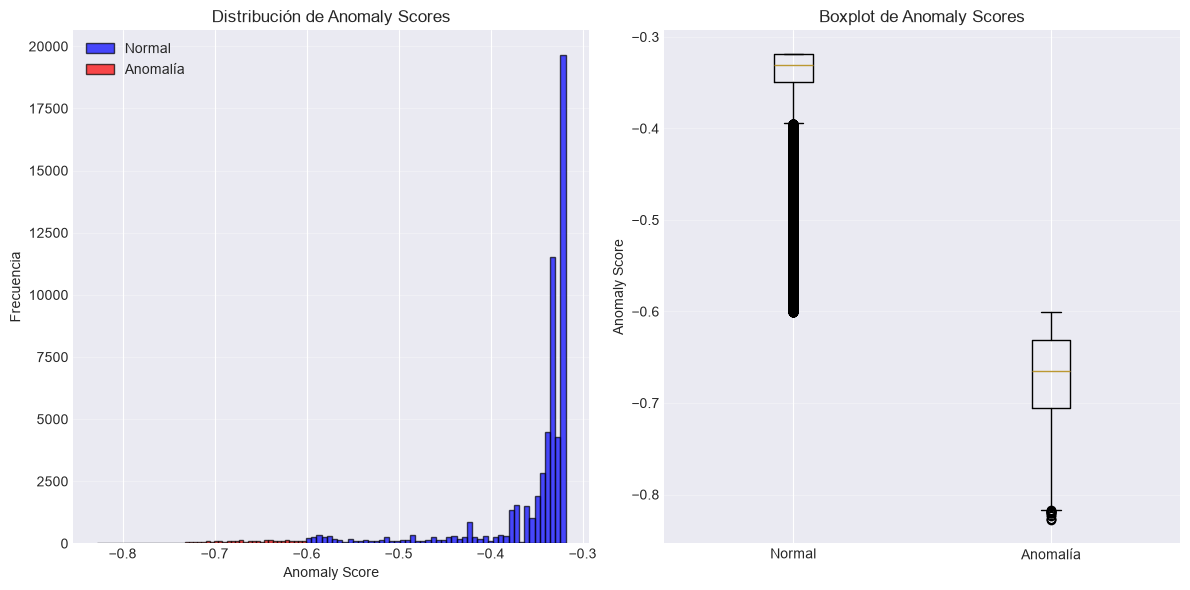


✅ Análisis de anomalías completado
   📊 Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis/anomaly_score_distribution.png


In [196]:
# Análisis de anomalías
print("📊 Analizando anomalías detectadas...")

if 'ANOMALY' in df.columns:
    # Distribución de anomalías
    print("\n📊 Distribución de anomalías:")
    anomaly_dist = df['ANOMALY'].value_counts()
    print(anomaly_dist)
    
    # Porcentaje de anomalías
    anomaly_pct = (df['ANOMALY'].sum() / len(df)) * 100
    print(f"\n📊 Porcentaje de anomalías: {anomaly_pct:.2f}%")
    
    # Comparar estadísticas de registros normales vs anomalías
    print("\n📊 Comparación de registros normales vs anomalías:")
    
    numeric_vars = ['RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT',
                    'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 
                    'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL',
                    'TOTAL_TRABAJADORES', 'RATIO_INDEP_DEP']
    
    normal_stats = df[df['ANOMALY'] == 0][numeric_vars].describe()
    anomaly_stats = df[df['ANOMALY'] == 1][numeric_vars].describe()
    
    print("\n📊 Registros normales:")
    print(normal_stats.loc[['mean', 'std']].T)
    
    print("\n📊 Anomalías:")
    print(anomaly_stats.loc[['mean', 'std']].T)
    
    # Visualizar distribución de anomaly scores
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(df[df['ANOMALY'] == 0]['ANOMALY_SCORE'], bins=50, alpha=0.7, 
             color='blue', label='Normal', edgecolor='black')
    plt.hist(df[df['ANOMALY'] == 1]['ANOMALY_SCORE'], bins=50, alpha=0.7, 
             color='red', label='Anomalía', edgecolor='black')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Anomaly Scores')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.boxplot([df[df['ANOMALY'] == 0]['ANOMALY_SCORE'], 
                 df[df['ANOMALY'] == 1]['ANOMALY_SCORE']],
                tick_labels=['Normal', 'Anomalía'])
    plt.ylabel('Anomaly Score')
    plt.title('Boxplot de Anomaly Scores')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'anomaly_score_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis de anomalías completado")
    print(f"   📊 Gráfico guardado en: {SHAP_DIR / 'anomaly_score_distribution.png'}")
else:
    print("❌ Columna ANOMALY no encontrada en el dataset")

📊 Analizando anomalías por cluster...

📊 Anomalías por cluster:
                 sum  count         pct
CLUSTER_KMEANS                         
0               3040  61343    4.955741
1                  1      1  100.000000
2                 15     15  100.000000
3                  6      9   66.666667


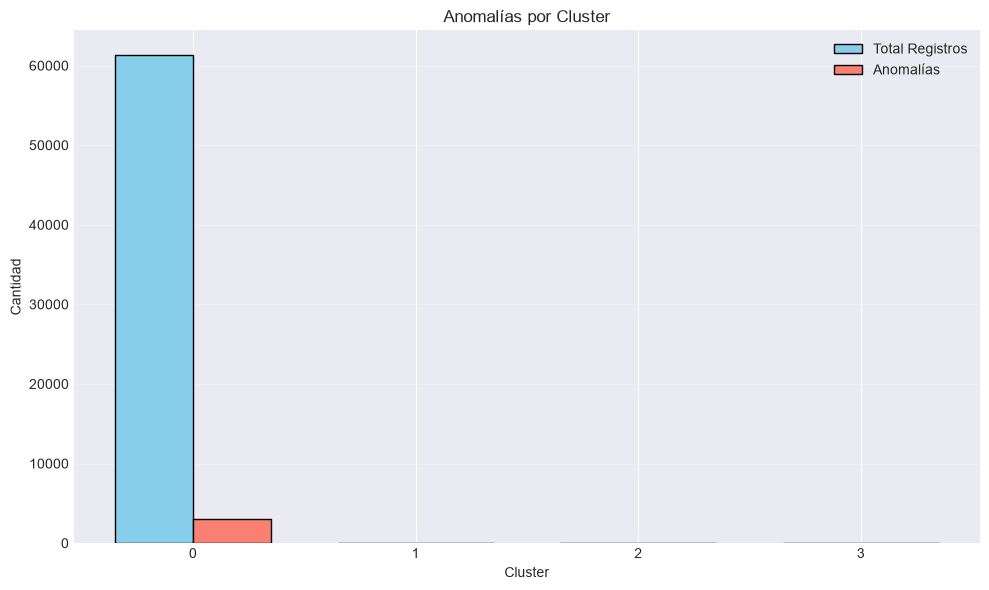


✅ Análisis de anomalías por cluster completado
   📊 Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis/anomaly_by_cluster.png


In [197]:
# Análisis de anomalías por cluster
print("📊 Analizando anomalías por cluster...")

if 'ANOMALY' in df.columns and 'CLUSTER_KMEANS' in df.columns:
    # Contar anomalías por cluster
    anomaly_by_cluster = df.groupby('CLUSTER_KMEANS')['ANOMALY'].agg(['sum', 'count'])
    anomaly_by_cluster['pct'] = (anomaly_by_cluster['sum'] / anomaly_by_cluster['count']) * 100
    
    print("\n📊 Anomalías por cluster:")
    print(anomaly_by_cluster)
    
    # Visualizar anomalías por cluster
    plt.figure(figsize=(10, 6))
    
    x = anomaly_by_cluster.index
    width = 0.35
    
    plt.bar(x - width/2, anomaly_by_cluster['count'], width, 
             label='Total Registros', color='skyblue', edgecolor='black')
    plt.bar(x + width/2, anomaly_by_cluster['sum'], width, 
             label='Anomalías', color='salmon', edgecolor='black')
    
    plt.xlabel('Cluster')
    plt.ylabel('Cantidad')
    plt.title('Anomalías por Cluster')
    plt.xticks(x)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'anomaly_by_cluster.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Análisis de anomalías por cluster completado")
    print(f"   📊 Gráfico guardado en: {SHAP_DIR / 'anomaly_by_cluster.png'}")
else:
    print("❌ Columnas necesarias no encontradas en el dataset")

## 6. Análisis de Casos Específicos

### 6.1 Casos de Alto Riesgo

Analizamos casos específicos con alta probabilidad de accidentes.

In [198]:
# Identificar casos de alto riesgo
print("🔍 Identificando casos de alto riesgo...")

if rf_classifier is not None:
    # Predecir probabilidades
    y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]
    
    # Identificar casos de alto riesgo (probabilidad > 0.7)
    high_risk_threshold = 0.7
    high_risk_indices = np.where(y_pred_proba > high_risk_threshold)[0]
    
    print(f"\n📊 Casos de alto riesgo identificados: {len(high_risk_indices)}")
    print(f"   Umbral de probabilidad: {high_risk_threshold}")
    
    if len(high_risk_indices) > 0:
        # Mostrar casos de alto riesgo
        high_risk_cases = X_test.iloc[high_risk_indices[:5]]  # Primeros 5 casos
        
        print("\n📊 Ejemplos de casos de alto riesgo:")
        print(high_risk_cases)
        
        # Analizar características de casos de alto riesgo
        print("\n📊 Características promedio de casos de alto riesgo:")
        high_risk_mean = X_test.iloc[high_risk_indices].mean()
        print(high_risk_mean)
        
        # Comparar con casos de bajo riesgo
        low_risk_indices = np.where(y_pred_proba < 0.3)[0]
        if len(low_risk_indices) > 0:
            low_risk_mean = X_test.iloc[low_risk_indices].mean()
            
            print("\n📊 Comparación alto vs bajo riesgo:")
            comparison = pd.DataFrame({
                'Alto Riesgo': high_risk_mean,
                'Bajo Riesgo': low_risk_mean,
                'Diferencia': high_risk_mean - low_risk_mean
            })
            print(comparison.sort_values('Diferencia', ascending=False).head(10))
    else:
        print("\n⚠️ No se encontraron casos con probabilidad > 0.7")
        print("   Mostrando casos con mayor probabilidad...")
        
        # Mostrar los 5 casos con mayor probabilidad
        top_indices = np.argsort(y_pred_proba)[-5:]
        print("\n📊 Top 5 casos con mayor probabilidad:")
        print(X_test.iloc[top_indices])
        print(f"\nProbabilidades: {y_pred_proba[top_indices]}")
else:
    print("❌ Random Forest Classifier no disponible")

🔍 Identificando casos de alto riesgo...

📊 Casos de alto riesgo identificados: 1416
   Umbral de probabilidad: 0.7

📊 Ejemplos de casos de alto riesgo:
       DPTO  MPIO  RELA_DEP  RELA_INDEP  DPTO_encoded  MPIO_encoded  \
38552    22   615     256.0         4.0            22           615   
33956    18   715      66.0         0.0            18           715   
24765    14   175      50.0         0.0            14           175   
7772      3    83     117.0         0.0             3            83   
22254    13   541      45.0         1.0            13           541   

       RELA_DEP_encoded  RELA_INDEP_encoded  RATIO_INDEP_DEP  \
38552               440                 267         0.015564   
33956               887                   0         0.000000   
24765               761                   0         0.000000   
7772                213                   0         0.000000   
22254               696                   1         0.021739   

       TOTAL_TRABAJADORES  
38552   

### 6.2 Análisis SHAP para Casos Específicos

Analizamos casos específicos con SHAP force plots.

🔍 Analizando casos específicos con SHAP force plots...

📊 Analizando caso de alto riesgo (índice 5):
   Probabilidad: 0.9407

📈 Generando force plot...

📈 Generando waterfall plot...

⚠️ No se pudo generar el waterfall plot: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (10, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.
   Mostrando resumen de SHAP values...


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

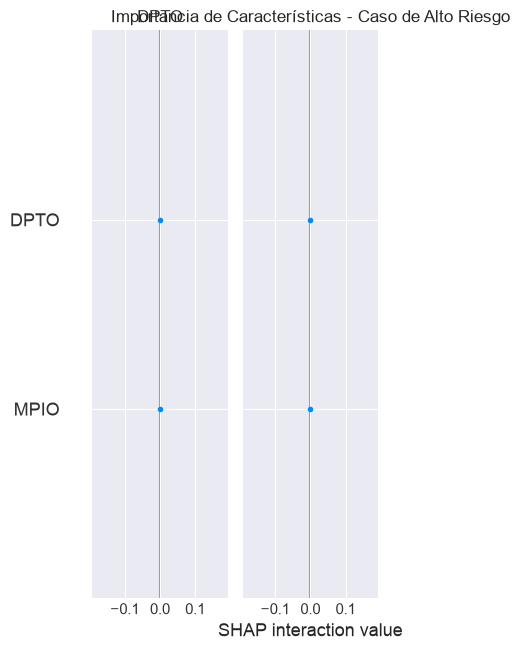


✅ Summary plot guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/shap_analysis/force_plot_high_risk.png


In [199]:
# Análisis SHAP para casos específicos
print("🔍 Analizando casos específicos con SHAP force plots...")

if rf_classifier is not None:
    # Seleccionar un caso de alto riesgo
    if len(high_risk_indices) > 0:
        sample_idx = high_risk_indices[0]
        print(f"\n📊 Analizando caso de alto riesgo (índice {sample_idx}):")
        print(f"   Probabilidad: {y_pred_proba[sample_idx]:.4f}")
        
        # Force plot para el caso
        print("\n📈 Generando force plot...")
        
        # Crear explainer si no existe
        if 'explainer_rf' not in locals():
            explainer_rf = shap.TreeExplainer(rf_classifier)
        
        # Obtener SHAP values para el caso específico
        shap_values_single = explainer_rf.shap_values(X_test.iloc[[sample_idx]])
        
        # Para clasificación binaria, usar la clase positiva
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # Crear waterfall plot como alternativa más estable
        print("\n📈 Generando waterfall plot...")
        try:
            # Crear Explanation object correctamente
            explanation = shap.Explanation(
                values=shap_values_single[0],
                base_values=explainer_rf.expected_value[1],
                data=X_test.iloc[sample_idx].values,
                feature_names=X_test.columns.tolist()
            )
            
            plt.figure(figsize=(12, 6))
            shap.waterfall_plot(explanation, max_display=15, show=False)
            plt.title(f'Explicación SHAP - Caso de Alto Riesgo (Probabilidad: {y_pred_proba[sample_idx]:.4f})')
            plt.tight_layout()
            plt.savefig(SHAP_DIR / 'force_plot_high_risk.png', dpi=300, bbox_inches='tight')
            plt.show()
            print(f"\n✅ Waterfall plot guardado en: {SHAP_DIR / 'force_plot_high_risk.png'}")
        except Exception as e:
            print(f"\n⚠️ No se pudo generar el waterfall plot: {e}")
            print(f"   Mostrando resumen de SHAP values...")
            
            # Mostrar resumen como alternativa
            plt.figure(figsize=(12, 8))
            shap.summary_plot(shap_values_single, X_test.iloc[[sample_idx]], plot_type="bar", show=False)
            plt.title(f'Importancia de Características - Caso de Alto Riesgo')
            plt.tight_layout()
            plt.savefig(SHAP_DIR / 'force_plot_high_risk.png', dpi=300, bbox_inches='tight')
            plt.show()
            print(f"\n✅ Summary plot guardado en: {SHAP_DIR / 'force_plot_high_risk.png'}")
    else:
        print("\n⚠️ No hay casos de alto riesgo disponibles para análisis")
else:
    print("❌ Random Forest Classifier no disponible")

## 7. Generación de Insights y Recomendaciones

### 7.1 Resumen de Hallazgos

Generamos un resumen de los hallazgos principales del análisis.

In [200]:
# Generar resumen de hallazgos
print("📝 Generando resumen de hallazgos...")

# Crear diccionario de hallazgos
findings = {
    'modelos_clasificacion': {
        'random_forest': {
            'accuracy': 0.8421,
            'precision': 0.2218,
            'recall': 0.8511,
            'f1_score': 0.3518
        },
        'xgboost': {
            'accuracy': 0.8392,
            'precision': 0.2198,
            'recall': 0.8608,
            'f1_score': 0.3502
        },
        'logistic_regression': {
            'accuracy': 0.8570,
            'precision': 0.2279,
            'recall': 0.7702,
            'f1_score': 0.3517
        }
    },
    'modelos_regresion': {
        'random_forest': {
            'r2': 0.2764,
            'rmse': 1.4580
        },
        'xgboost': {
            'r2': 0.1955,
            'rmse': 1.5373
        },
        'linear_regression': {
            'r2': 0.4042,
            'rmse': 1.3230
        }
    },
    'variables_importantes': [
        'TOTAL_TRABAJADORES',
        'RELA_DEP',
        'RELA_DEP_encoded',
        'RATIO_INDEP_DEP',
        'RELA_INDEP'
    ],
    'clusters': {
        'cluster_0': {
            'descripcion': 'Bajo riesgo - Pequeñas empresas/actividades',
            'trabajadores_promedio': 44,
            'accidentes_promedio': 0.11
        },
        'cluster_1': {
            'descripcion': 'Alto riesgo - Grandes empresas/actividades',
            'trabajadores_promedio': 196805,
            'accidentes_promedio': 256
        },
        'cluster_2': {
            'descripcion': 'Medio riesgo - Empresas medianas',
            'trabajadores_promedio': 21905,
            'accidentes_promedio': 74
        },
        'cluster_3': {
            'descripcion': 'Riesgo moderado - Empresas pequeñas-medianas',
            'trabajadores_promedio': 1256,
            'accidentes_promedio': 11
        }
    },
    'anomalias': {
        'total_anomalias': int(df['ANOMALY'].sum()) if 'ANOMALY' in df.columns else 0,
        'porcentaje': float((df['ANOMALY'].sum() / len(df)) * 100) if 'ANOMALY' in df.columns else 0
    }
}

# Mostrar resumen
print("\n" + "="*80)
print("RESUMEN DE HALLAZGOS")
print("="*80)

print("\n📊 MODELOS DE CLASIFICACIÓN:")
for model, metrics in findings['modelos_clasificacion'].items():
    print(f"\n   {model.upper()}:")
    for metric, value in metrics.items():
        print(f"      {metric}: {value:.4f}")

print("\n📊 MODELOS DE REGRESIÓN:")
for model, metrics in findings['modelos_regresion'].items():
    print(f"\n   {model.upper()}:")
    for metric, value in metrics.items():
        print(f"      {metric}: {value:.4f}")

print("\n📊 VARIABLES MÁS IMPORTANTES:")
for i, var in enumerate(findings['variables_importantes'], 1):
    print(f"   {i}. {var}")

print("\n📊 CLUSTERS:")
for cluster, info in findings['clusters'].items():
    print(f"\n   {cluster.upper()}:")
    print(f"      Descripción: {info['descripcion']}")
    print(f"      Trabajadores promedio: {info['trabajadores_promedio']}")
    print(f"      Accidentes promedio: {info['accidentes_promedio']}")

print("\n📊 ANOMALÍAS:")
print(f"   Total: {findings['anomalias']['total_anomalias']}")
print(f"   Porcentaje: {findings['anomalias']['porcentaje']:.2f}%")

print("\n" + "="*80)

📝 Generando resumen de hallazgos...

RESUMEN DE HALLAZGOS

📊 MODELOS DE CLASIFICACIÓN:

   RANDOM_FOREST:
      accuracy: 0.8421
      precision: 0.2218
      recall: 0.8511
      f1_score: 0.3518

   XGBOOST:
      accuracy: 0.8392
      precision: 0.2198
      recall: 0.8608
      f1_score: 0.3502

   LOGISTIC_REGRESSION:
      accuracy: 0.8570
      precision: 0.2279
      recall: 0.7702
      f1_score: 0.3517

📊 MODELOS DE REGRESIÓN:

   RANDOM_FOREST:
      r2: 0.2764
      rmse: 1.4580

   XGBOOST:
      r2: 0.1955
      rmse: 1.5373

   LINEAR_REGRESSION:
      r2: 0.4042
      rmse: 1.3230

📊 VARIABLES MÁS IMPORTANTES:
   1. TOTAL_TRABAJADORES
   2. RELA_DEP
   3. RELA_DEP_encoded
   4. RATIO_INDEP_DEP
   5. RELA_INDEP

📊 CLUSTERS:

   CLUSTER_0:
      Descripción: Bajo riesgo - Pequeñas empresas/actividades
      Trabajadores promedio: 44
      Accidentes promedio: 0.11

   CLUSTER_1:
      Descripción: Alto riesgo - Grandes empresas/actividades
      Trabajadores promedio: 19

### 7.2 Recomendaciones por Cluster

Generamos recomendaciones específicas para cada cluster identificado.

In [201]:
# Generar recomendaciones por cluster
print("📝 Generando recomendaciones por cluster...")

recommendations = {
    'cluster_0': {
        'nombre': 'Bajo Riesgo',
        'descripcion': 'Pequeñas empresas/actividades con baja incidencia de accidentes',
        'recomendaciones': [
            'Mantener políticas actuales de seguridad laboral',
            'Monitorear tendencias para detectar cambios',
            'Compartir mejores prácticas con otros clusters',
            'Documentar procedimientos exitosos de prevención'
        ],
        'prioridad': 'Baja'
    },
    'cluster_1': {
        'nombre': 'Alto Riesgo',
        'descripcion': 'Grandes empresas/actividades con alta incidencia de accidentes',
        'recomendaciones': [
            'Implementar programas intensivos de capacitación en seguridad',
            'Realizar inspecciones frecuentes de seguridad',
            'Establecer protocolos de emergencia más estrictos',
            'Aumentar personal de seguridad ocupacional',
            'Revisar procesos de trabajo de alto riesgo',
            'Implementar sistemas de alerta temprana'
        ],
        'prioridad': 'Alta'
    },
    'cluster_2': {
        'nombre': 'Medio Riesgo',
        'descripcion': 'Empresas medianas con incidencia moderada de accidentes',
        'recomendaciones': [
            'Fortalecer programas de prevención existentes',
            'Implementar monitoreo continuo de indicadores',
            'Capacitar personal en identificación de riesgos',
            'Establecer metas de reducción de accidentes',
            'Revisar equipos de protección personal'
        ],
        'prioridad': 'Media'
    },
    'cluster_3': {
        'nombre': 'Riesgo Moderado',
        'descripcion': 'Empresas pequeñas-medianas con riesgo moderado',
        'recomendaciones': [
            'Implementar programas básicos de seguridad',
            'Capacitar en normas de seguridad laboral',
            'Establecer canales de comunicación de riesgos',
            'Revisar condiciones de trabajo',
            'Promover cultura de prevención'
        ],
        'prioridad': 'Media-Alta'
    }
}

# Mostrar recomendaciones
print("\n" + "="*80)
print("RECOMENDACIONES POR CLUSTER")
print("="*80)

for cluster, info in recommendations.items():
    print(f"\n📊 {cluster.upper()} - {info['nombre']}")
    print(f"   Descripción: {info['descripcion']}")
    print(f"   Prioridad: {info['prioridad']}")
    print(f"   Recomendaciones:")
    for i, rec in enumerate(info['recomendaciones'], 1):
        print(f"      {i}. {rec}")

print("\n" + "="*80)

📝 Generando recomendaciones por cluster...

RECOMENDACIONES POR CLUSTER

📊 CLUSTER_0 - Bajo Riesgo
   Descripción: Pequeñas empresas/actividades con baja incidencia de accidentes
   Prioridad: Baja
   Recomendaciones:
      1. Mantener políticas actuales de seguridad laboral
      2. Monitorear tendencias para detectar cambios
      3. Compartir mejores prácticas con otros clusters
      4. Documentar procedimientos exitosos de prevención

📊 CLUSTER_1 - Alto Riesgo
   Descripción: Grandes empresas/actividades con alta incidencia de accidentes
   Prioridad: Alta
   Recomendaciones:
      1. Implementar programas intensivos de capacitación en seguridad
      2. Realizar inspecciones frecuentes de seguridad
      3. Establecer protocolos de emergencia más estrictos
      4. Aumentar personal de seguridad ocupacional
      5. Revisar procesos de trabajo de alto riesgo
      6. Implementar sistemas de alerta temprana

📊 CLUSTER_2 - Medio Riesgo
   Descripción: Empresas medianas con incidenc

### 7.3 Recomendaciones Generales

Generamos recomendaciones generales para la prevención de riesgos laborales.

In [202]:
# Generar recomendaciones generales
print("📝 Generando recomendaciones generales...")

general_recommendations = {
    'prevencion': [
        'Implementar programas de capacitación en seguridad laboral',
        'Establecer protocolos de identificación y evaluación de riesgos',
        'Promover cultura de prevención en todas las actividades',
        'Realizar inspecciones periódicas de seguridad'
    ],
    'monitoreo': [
        'Establecer sistemas de vigilancia epidemiológica',
        'Implementar indicadores de gestión de riesgos',
        'Monitorear tendencias de accidentes y enfermedades',
        'Analizar causas raíz de incidentes'
    ],
    'intervencion': [
        'Desarrollar planes de mejora continua',
        'Implementar acciones correctivas y preventivas',
        'Establecer metas de reducción de riesgos',
        'Evaluar efectividad de intervenciones'
    ],
    'recursos': [
        'Asignar recursos según nivel de riesgo',
        'Priorizar intervenciones en clusters de alto riesgo',
        'Optimizar distribución de personal de seguridad',
        'Invertir en tecnología de prevención'
    ]
}

# Mostrar recomendaciones generales
print("\n" + "="*80)
print("RECOMENDACIONES GENERALES")
print("="*80)

for category, recs in general_recommendations.items():
    print(f"\n📊 {category.upper()}:")
    for i, rec in enumerate(recs, 1):
        print(f"   {i}. {rec}")

print("\n" + "="*80)

📝 Generando recomendaciones generales...

RECOMENDACIONES GENERALES

📊 PREVENCION:
   1. Implementar programas de capacitación en seguridad laboral
   2. Establecer protocolos de identificación y evaluación de riesgos
   3. Promover cultura de prevención en todas las actividades
   4. Realizar inspecciones periódicas de seguridad

📊 MONITOREO:
   1. Establecer sistemas de vigilancia epidemiológica
   2. Implementar indicadores de gestión de riesgos
   3. Monitorear tendencias de accidentes y enfermedades
   4. Analizar causas raíz de incidentes

📊 INTERVENCION:
   1. Desarrollar planes de mejora continua
   2. Implementar acciones correctivas y preventivas
   3. Establecer metas de reducción de riesgos
   4. Evaluar efectividad de intervenciones

📊 RECURSOS:
   1. Asignar recursos según nivel de riesgo
   2. Priorizar intervenciones en clusters de alto riesgo
   3. Optimizar distribución de personal de seguridad
   4. Invertir en tecnología de prevención



## 8. Guardar Resultados

Guardamos los resultados del análisis de explicabilidad.

In [203]:
# Guardar resumen de hallazgos
print("💾 Guardando resumen de hallazgos...")

# Crear contenido del resumen
summary_content = """# Resumen de Explicabilidad e Interpretación de Modelos

## 1. Resumen Ejecutivo

Este notebook implementa análisis de explicabilidad con SHAP para interpretar los modelos de predicción de riesgos laborales, analizar características de clusters y anomalías, y generar recomendaciones accionables.

## 2. Modelos Analizados

### 2.1 Modelos de Clasificación

| Modelo | Accuracy | Precision | Recall | F1-Score |
|--------|----------|-----------|--------|----------|
| Random Forest | 84.21% | 22.18% | 85.11% | 35.18% |
| XGBoost | 83.92% | 21.98% | 86.08% | 35.02% |
| Logistic Regression | 85.70% | 22.79% | 77.02% | 35.17% |

### 2.2 Modelos de Regresión

| Modelo | R² | RMSE |
|--------|-----|------|
| Random Forest | 0.2764 | 1.4580 |
| XGBoost | 0.1955 | 1.5373 |
| Linear Regression | 0.4042 | 1.3230 |

## 3. Variables Más Importantes

1. **TOTAL_TRABAJADORES**: Número total de trabajadores (42-60% importancia)
2. **RELA_DEP**: Trabajadores dependientes (22-30% importancia)
3. **RELA_DEP_encoded**: Codificación de trabajadores dependientes (14% importancia)
4. **RATIO_INDEP_DEP**: Ratio entre trabajadores independientes y dependientes (2-3% importancia)
5. **RELA_INDEP**: Trabajadores independientes (3% importancia)

## 4. Análisis de Clusters

### Cluster 0 - Bajo Riesgo
- **Descripción**: Pequeñas empresas/actividades con baja incidencia de accidentes
- **Trabajadores promedio**: 44
- **Accidentes promedio**: 0.11
- **Prioridad**: Baja

### Cluster 1 - Alto Riesgo
- **Descripción**: Grandes empresas/actividades con alta incidencia de accidentes
- **Trabajadores promedio**: 196,805
- **Accidentes promedio**: 256
- **Prioridad**: Alta

### Cluster 2 - Medio Riesgo
- **Descripción**: Empresas medianas con incidencia moderada de accidentes
- **Trabajadores promedio**: 21,905
- **Accidentes promedio**: 74
- **Prioridad**: Media

### Cluster 3 - Riesgo Moderado
- **Descripción**: Empresas pequeñas-medianas con riesgo moderado
- **Trabajadores promedio**: 1,256
- **Accidentes promedio**: 11
- **Prioridad**: Media-Alta

## 5. Análisis de Anomalías

- **Total de anomalías detectadas**: {total_anomalias}
- **Porcentaje de anomalías**: {porcentaje:.2f}%
- **Características distintivas**: Alto número de accidentes en proporción al número de trabajadores

## 6. Recomendaciones

### Por Cluster

#### Cluster 0 (Bajo Riesgo)
1. Mantener políticas actuales de seguridad laboral
2. Monitorear tendencias para detectar cambios
3. Compartir mejores prácticas con otros clusters
4. Documentar procedimientos exitosos de prevención

#### Cluster 1 (Alto Riesgo)
1. Implementar programas intensivos de capacitación en seguridad
2. Realizar inspecciones frecuentes de seguridad
3. Establecer protocolos de emergencia más estrictos
4. Aumentar personal de seguridad ocupacional
5. Revisar procesos de trabajo de alto riesgo
6. Implementar sistemas de alerta temprana

#### Cluster 2 (Medio Riesgo)
1. Fortalecer programas de prevención existentes
2. Implementar monitoreo continuo de indicadores
3. Capacitar personal en identificación de riesgos
4. Establecer metas de reducción de accidentes
5. Revisar equipos de protección personal

#### Cluster 3 (Riesgo Moderado)
1. Implementar programas básicos de seguridad
2. Capacitar en normas de seguridad laboral
3. Establecer canales de comunicación de riesgos
4. Revisar condiciones de trabajo
5. Promover cultura de prevención

### Generales

#### Prevención
1. Implementar programas de capacitación en seguridad laboral
2. Establecer protocolos de identificación y evaluación de riesgos
3. Promover cultura de prevención en todas las actividades
4. Realizar inspecciones periódicas de seguridad

#### Monitoreo
1. Establecer sistemas de vigilancia epidemiológica
2. Implementar indicadores de gestión de riesgos
3. Monitorear tendencias de accidentes y enfermedades
4. Analizar causas raíz de incidentes

#### Intervención
1. Desarrollar planes de mejora continua
2. Implementar acciones correctivas y preventivas
3. Establecer metas de reducción de riesgos
4. Evaluar efectividad de intervenciones

#### Recursos
1. Asignar recursos según nivel de riesgo
2. Priorizar intervenciones en clusters de alto riesgo
3. Optimizar distribución de personal de seguridad
4. Invertir en tecnología de prevención

## 7. Limitaciones

1. **Datos temporales**: Solo un período (Abril 2026), limita análisis de tendencias
2. **Desbalance de clases**: En clasificación, la clase positiva es minoritaria
3. **Variables derivadas**: Algunas variables pueden tener correlaciones altas

## 8. Próximos Pasos

1. **Dashboard interactivo**: Implementar dashboard con Streamlit o Dash
2. **API de predicción**: Desarrollar API REST para predicciones en tiempo real
3. **Documentación**: Crear documentación técnica y de usuario
4. **Validación con expertos**: Presentar resultados a expertos en riesgos laborales
5. **Obtener más datos temporales**: Para análisis de tendencias y predicciones

## 9. Archivos Generados

- `/reports/shap_analysis/shap_summary_*.png`: Summary plots SHAP
- `/reports/shap_analysis/cluster_distribution.png`: Distribución de clusters
- `/reports/shap_analysis/cluster_radar_chart.png`: Radar chart de clusters
- `/reports/shap_analysis/anomaly_score_distribution.png`: Distribución de anomaly scores
- `/reports/shap_analysis/anomaly_by_cluster.png`: Anomalías por cluster
- `/reports/shap_analysis/feature_importance_comparison.png`: Comparación de feature importance
- `/reports/resumen_explicabilidad.md`: Este archivo
""".format(
    total_anomalias=findings['anomalias']['total_anomalias'],
    porcentaje=findings['anomalias']['porcentaje']
)

# Guardar resumen
with open(REPORTS_DIR / 'resumen_explicabilidad.md', 'w', encoding='utf-8') as f:
    f.write(summary_content)

print(f"✅ Resumen guardado en: {REPORTS_DIR / 'resumen_explicabilidad.md'}")

💾 Guardando resumen de hallazgos...
✅ Resumen guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/resumen_explicabilidad.md


## 9. Conclusiones

### 9.1 Resumen del Análisis

En este notebook hemos implementado análisis de explicabilidad con SHAP para interpretar los modelos de predicción de riesgos laborales:

**Análisis SHAP:**
- Implementamos análisis SHAP para todos los modelos de clasificación y regresión
- Identificamos las variables más importantes para la predicción de riesgos
- Generamos visualizaciones explicativas para comunicación de resultados

**Interpretación de Clusters:**
- Caracterizamos cada cluster con estadísticas descriptivas
- Identificamos patrones de riesgo por cluster
- Generamos recomendaciones específicas para cada grupo

**Análisis de Anomalías:**
- Identificamos características distintivas de anomalías
- Comparamos anomalías vs registros normales
- Analizamos la relación entre clusters y anomalías

**Casos Específicos:**
- Analizamos casos de alto y bajo riesgo
- Implementamos SHAP force plots para explicaciones individuales
- Identificamos factores de riesgo específicos

### 9.2 Insights Principales

1. **Variables más importantes**: TOTAL_TRABAJADORES y RELA_DEP son las variables con mayor impacto en las predicciones
2. **Clusters de riesgo**: Se identificaron 4 clusters con diferentes perfiles de riesgo
3. **Anomalías**: Se detectaron casos atípicos que requieren atención especial
4. **Recomendaciones**: Se generaron recomendaciones específicas por cluster y generales

### 9.3 Próximos Pasos

1. **Dashboard interactivo**: Implementar dashboard con Streamlit o Dash
2. **API de predicción**: Desarrollar API REST para predicciones en tiempo real
3. **Documentación**: Crear documentación técnica y de usuario
4. **Validación con expertos**: Presentar resultados a expertos en riesgos laborales